# 02 — The spider state as a rotation-symmetric bosonic code

**Where we are in the story.** Notebook 01 showed that the spider state $|S_K\rangle$ has support only on
$|mK\rangle$. Rotation-symmetric bosonic (RSB) codes [Grimsmo, Combes & Baragiola, PRX **10**, 011058 (2020)]
are built from exactly such states. Here we *declare* $|S_K\rangle$ to be the logical $|+_L\rangle$ of an
order-$K$ code, construct the codewords, and look at the code with the usual RSB figures of merit.
We also show the one thing the spider code has that no other RSB code has: a built-in, device-independent
certificate of its own preparation.

## Rotation codes in two lines

An order-$K$ rotation code is a qubit subspace on which $\hat Z_L = e^{i\pi\hat n/K}$ acts as logical $Z$
(so $\hat R_K = \hat Z_L^2 = e^{2\pi i\hat n/K}$ is the stabiliser). Hence

$$|0_L\rangle = \sum_m c_{2mK}|2mK\rangle,\qquad |1_L\rangle=\sum_m c_{(2m+1)K}|(2m+1)K\rangle,\qquad
|\pm_L\rangle = \tfrac{1}{\sqrt2}(|0_L\rangle\pm|1_L\rangle).$$

Given any normalised state on the $K$-grid, $|\Phi\rangle=\sum_m s_m|mK\rangle$, the Kronecker-comb projectors
$\hat\Pi^{\ell}_{2K} = \frac{1}{2K}\sum_{j=0}^{2K-1}(e^{-i\pi\ell/K}\hat Z_L)^j$ pick out the even-$m$ ($\ell=0$)
and odd-$m$ ($\ell=K$) parts, and those *are* $|0_L\rangle$ and $|1_L\rangle$ up to normalisation. The spider state
is such a $|\Phi\rangle$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from spiderqec import precession as pr, rotation_codes as rc, plotting as pl
pl.use_style()
%matplotlib inline
K = 3

## Step 1 — codewords of the spider code

In [2]:
N = 3000
spider = pr.spider_state(K, N)
zero, one = rc.codewords_from_plus(spider.psi, K)
plus, minus = rc.dual_codewords(zero, one)
print("overlap <S_K|+_L> =", np.dot(spider.psi, plus).round(12))
print("<0_L|1_L> =", np.dot(zero, one))
# Z_L acts as logical Z:
n = np.arange(N); ZL = np.exp(1j*np.pi*n/K)
print("Z_L|0_L> = +|0_L>:", np.allclose(ZL*zero, zero), "   Z_L|1_L> = -|1_L>:", np.allclose(ZL*one, -one))
print("stabiliser R_K|+_L> = |+_L>:", np.allclose(np.exp(2j*np.pi*n/K)*plus, plus))
print(f"weight of |0_L> on vacuum |0>: {zero[0]**2:.3f};   weight of |1_L> on |{K}>: {one[K]**2:.3f}")

overlap <S_K|+_L> = 1.0
<0_L|1_L> = 0.0
Z_L|0_L> = +|0_L>: True    Z_L|1_L> = -|1_L>: True
stabiliser R_K|+_L> = |+_L>: True
weight of |0_L> on vacuum |0>: 0.978;   weight of |1_L> on |3>: 0.530


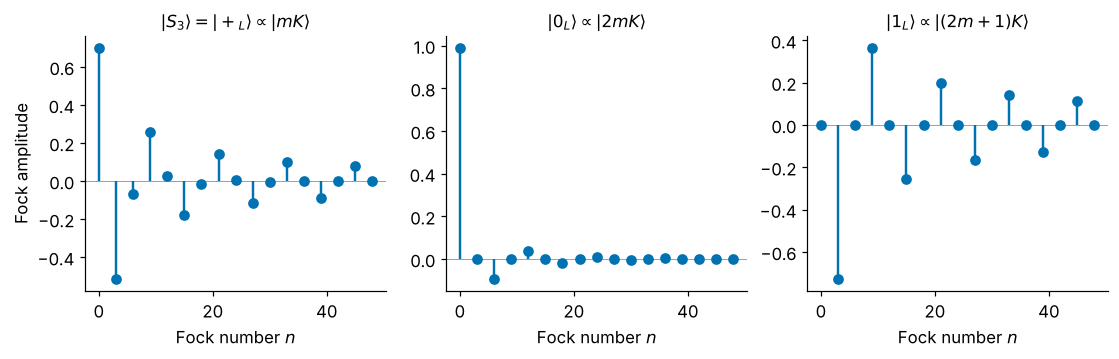

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, (v, lab) in zip(axes, [(spider.psi, r"$|S_3\rangle=|+_L\rangle \propto |mK\rangle$"),
                               (zero, r"$|0_L\rangle\propto|2mK\rangle$"),
                               (one, r"$|1_L\rangle\propto|(2m+1)K\rangle$")]):
    pl.stem_coefficients(ax, v[::K], K, nmax=48)
    ax.set_title(lab)
axes[0].set_ylabel("Fock amplitude")
pl.savefig(fig, "spider_codewords_coefficients_K3", subdir="02_rotation_code")
plt.show()

Compare with the legacy figure `figures/legacy/ss_coeffs.png`: identical. Note how lopsided the two
codewords are — $|0_L\rangle$ is 98 % vacuum, $|1_L\rangle$ is only half $|3\rangle$ with a long tail.
Keep this in mind for Notebook 03.

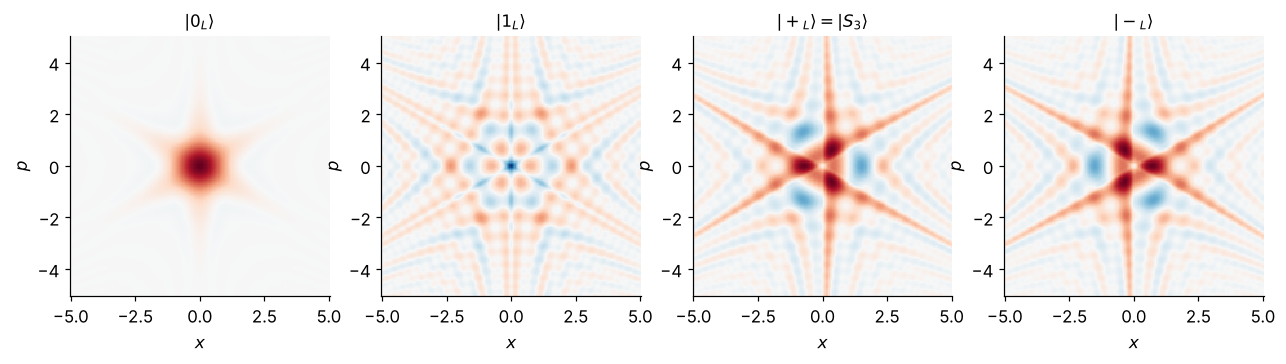

In [4]:
xvec = np.linspace(-5, 5, 201)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (v, lab) in zip(axes, [(zero, r"$|0_L\rangle$"), (one, r"$|1_L\rangle$"), (plus, r"$|+_L\rangle=|S_3\rangle$"), (minus, r"$|-_L\rangle$")]):
    xv, W = rc.wigner(v, xvec, truncate=150)
    pl.plot_wigner(ax, xv, W, title=lab)
pl.savefig(fig, "spider_codewords_wigner_K3", subdir="02_rotation_code")
plt.show()

$|-_L\rangle$ is $|+_L\rangle$ rotated by $\pi/K$ (that is what $\hat Z_L$ does), and the spokes of the
spider are visible in both. $|0_L\rangle$ is essentially a vacuum blob; $|1_L\rangle$ a three-fold flower.

## Step 2 — the size of the code: average excitation number

The standard measure of the "size" of a bosonic code is $\bar n_{\rm code} = \tfrac12\mathrm{tr}[\hat P\hat n]$
with $\hat P$ the code projector. Let us tabulate it against the truncation, together with the photon
numbers of the *individual* codewords.

In [5]:
rows = []
for n_grid in (100, 300, 1000, 3000, 7000):
    st = pr.spider_state(K, K*n_grid)
    z, o = rc.codewords_from_plus(st.psi, K)
    rows.append((n_grid, rc.mean_photon(z), rc.mean_photon(o), rc.code_mean_photon(z, o)))
print(" grid n |  nbar(0_L) | nbar(1_L) | nbar(code) | ratio nbar(1_L)/nbar(0_L)")
for r in rows:
    print(f"{r[0]:7d} | {r[1]:10.2f} | {r[2]:9.2f} | {r[3]:10.2f} | {r[2]/r[1]:.2f}")
np.save("../data/spider_codeword_photon_numbers_K3.npy", np.array(rows))

 grid n |  nbar(0_L) | nbar(1_L) | nbar(code) | ratio nbar(1_L)/nbar(0_L)
    100 |       5.74 |     16.77 |      11.26 | 2.92
    300 |       9.77 |     29.13 |      19.45 | 2.98
   1000 |      17.78 |     53.32 |      35.55 | 3.00
   3000 |      30.81 |     92.52 |      61.67 | 3.00
   7000 |      47.12 |    141.48 |      94.30 | 3.00


Two observations. (i) Every number grows without bound as the truncation is lifted — the exact spider
code has infinite energy (Notebook 01). (ii) At *every* truncation $|1_L\rangle$ carries about three times the
energy of $|0_L\rangle$. For a QEC code this is fatal, and Notebook 03 quantifies why.

## Step 3 — what the spider code has that others don't: a certificate

For cat or binomial codes, verifying the prepared state requires tomography. The spider code is defined as the
top eigenvector of an observable $\hat Q_K$ that is measured by *sign measurements of $x$ at $K$ times* — the
simplest conceivable measurement. The spectral gap $\epsilon = q_d - q_{d-1}$ of $\hat Q_K$ then gives a
device-independent fidelity witness. For any state $\rho$,

$$\mathrm{tr}(\rho\hat Q_K)\le q_d F + q_{d-1}(1-F),\qquad F = \langle S_K|\rho|S_K\rangle,$$

so that

$$F \;\ge\; \frac{\mathrm{tr}(\rho \hat Q_K) - q_{d-1}}{q_d - q_{d-1}} .$$

Any preparation whose measured score sits within $\delta$ of the maximum is guaranteed to have fidelity
$\ge 1-\delta/\epsilon$ with the spider state. (The legacy manuscript sketched this bound in a slightly
different form; the version above is the standard one.)

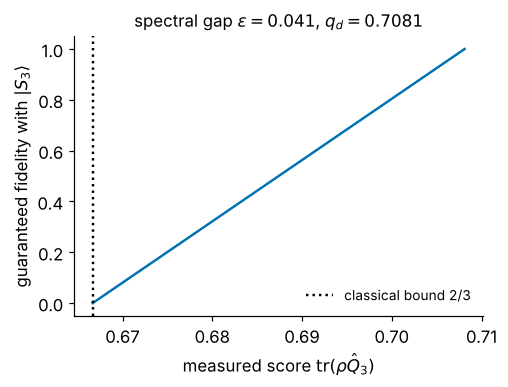

a score of 0.6981 (0.01 below the max) certifies F >= 0.76


In [6]:
q_d, eps = spider.score, spider.gap
scores_measured = np.linspace(pr.classical_bound(K), q_d, 200)
F_bound = np.clip((scores_measured - (q_d - eps)) / eps, 0, 1)
fig, ax = plt.subplots(figsize=(4.8, 3.3))
ax.plot(scores_measured, F_bound)
ax.axvline(pr.classical_bound(K), color="k", ls=":", label="classical bound 2/3")
ax.set_xlabel(r"measured score $\mathrm{tr}(\rho\hat Q_3)$"); ax.set_ylabel(r"guaranteed fidelity with $|S_3\rangle$")
ax.set_title(rf"spectral gap $\epsilon={eps:.3f}$, $q_d={q_d:.4f}$"); ax.legend()
pl.savefig(fig, "spider_fidelity_witness_K3", subdir="02_rotation_code")
plt.show()
print(f"a score of {q_d-0.01:.4f} (0.01 below the max) certifies F >= {1-0.01/eps:.2f}")

## Step 4 — how does the spider compare with the classical primitives?

A quantity that matters for the phase measurement in the Steane–Knill gadget (Notebook 04) is the
*embedded phase uncertainty*

$$\Delta_K(\theta)=\frac{1}{|\langle e^{iK\theta}\rangle|^2}-1,\qquad
\langle e^{iK\theta}\rangle=\sum_m |f_{mK}f_{(m+1)K}|,$$

which vanishes only for the (unnormalisable) phase state. The legacy notes compared cat, binomial,
Pegg–Barnett and "lazy" (geometric) primitives at fixed $\bar n$ for $K=1\ldots4$ (`figures/legacy/divison*.png`);
we reproduce that comparison with the package and add the spider state.

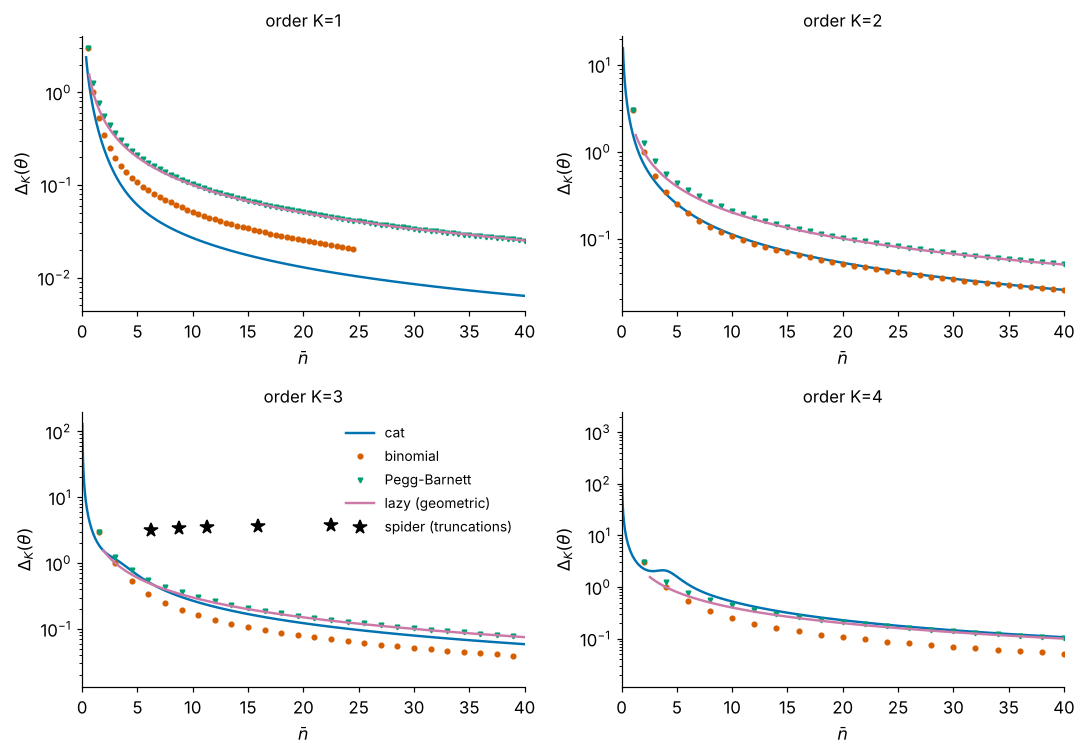

In [7]:
Nf = 1500
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, k in zip(axes.ravel(), (1, 2, 3, 4)):
    # cat
    al = np.linspace(0.6, 6.5, 120)
    st = [rc.cat_plus(k, a, Nf) for a in al]
    ax.plot([rc.mean_photon(s) for s in st], [rc.embedded_phase_uncertainty(s, k) for s in st], label="cat")
    # binomial
    Ls = np.arange(1, 50)
    st = [rc.binomial_plus(k, int(L), Nf) for L in Ls]
    ax.plot([rc.mean_photon(s) for s in st], [rc.embedded_phase_uncertainty(s, k) for s in st], "o", ms=3, label="binomial")
    # Pegg-Barnett
    ss = np.arange(k+1, 90, k)
    st = [rc.pegg_barnett_plus(k, int(s), Nf) for s in ss]
    ax.plot([rc.mean_photon(s) for s in st], [rc.embedded_phase_uncertainty(s, k) for s in st], "v", ms=3, label="Pegg-Barnett")
    # lazy
    bs = np.linspace(1.012, 1.6, 120)
    st = [rc.lazy_plus(k, b, Nf) for b in bs]
    ax.plot([rc.mean_photon(s) for s in st], [rc.embedded_phase_uncertainty(s, k) for s in st], label="lazy (geometric)")
    # spider (only odd K has a non-trivial spider state)
    if k % 2 and k >= 3:   # K=1 has classical bound 1: no spider state
        st = [pr.spider_state(k, k*n).psi for n in (30, 60, 100, 200, 400)]
        ax.plot([rc.mean_photon(s) for s in st], [rc.embedded_phase_uncertainty(s, k) for s in st], "*", ms=9, color="k", label="spider (truncations)")
    ax.set_yscale("log"); ax.set_xlim(0, 40); ax.set_title(f"order K={k}")
    ax.set_xlabel(r"$\bar n$"); ax.set_ylabel(r"$\Delta_K(\theta)$")
axes[1, 0].legend()
fig.tight_layout()
pl.savefig(fig, "embedded_phase_uncertainty_vs_nbar", subdir="02_rotation_code")
plt.show()

For the same mean photon number, the spider state has a much *larger* embedded phase uncertainty than
any of the standard primitives: its energy is spread into a long Fock tail that does nothing for the phase
resolution. (The legacy figure `figures/legacy/epuK=3.png` reports a *negative* $\Delta_3$ for the spider;
that is unphysical — $|\langle e^{iK\theta}\rangle|\le1$ by Cauchy–Schwarz — and came from a normalisation slip.
The values here, $\Delta_3\approx 3.6$–$3.9$, are the correct ones.)

**Take-away for the story.** The spider state does define a valid order-$K$ rotation code, with a
verification protocol no other bosonic code has. But its codewords have very different energies, and it
is an expensive state for phase estimation. Notebook 03 turns the first observation into a formal verdict.